In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


*Importations*

In [3]:
import pandas as pd
import glob
import os
import glob
import pandas as pd
import seaborn as sns
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import GroupShuffleSplit
from tensorflow.keras.applications import ResNet50V2


*Fixer les "Seeds*

In [4]:
# Fixer la graine pour toutes les bibliothèques
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

*Extraction des fichiers*

In [5]:
# Les chemins
zip_path = "/content/drive/MyDrive/Projet_Ruban_rose/archive.zip"
destination_path = "/content/data"

# Vérification
if not os.path.exists(destination_path):
    print("Début de l'extraction des données...")
    !mkdir -p {destination_path}
    !unzip -q "{zip_path}" -d {destination_path}
    print(" Extraction terminée avec succès !")
else:
    print(" Les données sont déjà présentes dans /content/data")

# Chemin
path = destination_path

Début de l'extraction des données...
 Extraction terminée avec succès !


**EDA**

*indexation des images*

In [6]:
# Récupèrer les chemins de fichiers .png
all_images = glob.glob('/content/data/**/*.png', recursive=True)

data = []
for path in all_images:
    # Récupère le nom du dossier parent
    folder_name = path.split('/')[-2]

    # Logique de conversion flexible
    if folder_name == '1' or 'positive' in folder_name.lower():
        label = 1
    elif folder_name == '0' or 'negative' in folder_name.lower():
        label = 0
    else:
        continue

    # Extraire l'ID du patient
    patient_id = path.split('/')[-3]

    data.append({'path': path, 'patient_id': patient_id, 'label': label})

df = pd.DataFrame(data)

print(f"Total d'images indexées : {len(df)}")
print(df['label'].value_counts())

Total d'images indexées : 157572
label
1    78786
0    78786
Name: count, dtype: int64


Le dataset présente une distribution strictement égale entre la Classe 0 (Sain) et la Classe 1 (IDC) avec 78 786 images chacune.

C'est un atout majeur pour l'entraînement. Le modèle ne sera pas biaisé vers une classe dominante, et la métrique Accuracy sera ici un indicateur fiable de performance, bien que nous surveillerons aussi le Recall pour minimiser les faux négatifs.

*Analyse de l'équilibre*

L'importance de la précision du diagnostic necessite de savoir si nos données sont équilibrées.

label
1    78786
0    78786
Name: count, dtype: int64


/tmp/ipykernel_851/938638939.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=['skyblue', 'salmon'])


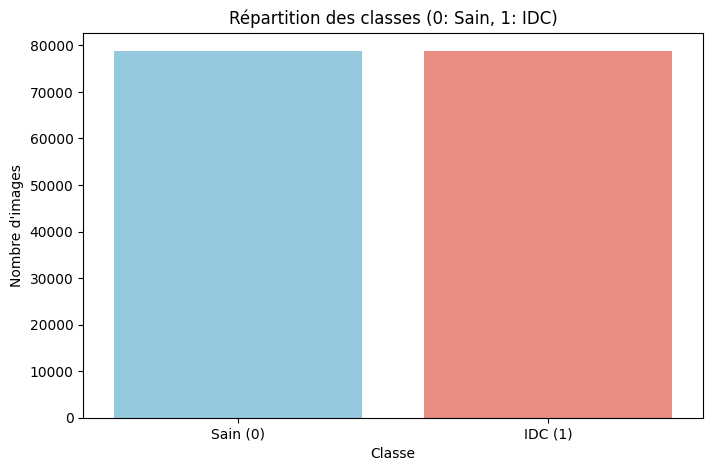

In [7]:
# Comptaer les classes
counts = df['label'].value_counts()
print(counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, palette=['skyblue', 'salmon'])
plt.title('Répartition des classes (0: Sain, 1: IDC)')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'images')
plt.xticks([0, 1], ['Sain (0)', 'IDC (1)'])
plt.show()

*Analyse par Patient*

Dans ce dataset, chaque patient possède plusieurs images. Il est donc intéressant de voir combien d'images on a par patient en moyenne.

Nombre de patients uniques : 279
Exemples d'IDs patients : ['10275' '14304' '12909' '10254' '12901']
Nombre moyen d'images par patient : 564.77
Minimum d'images pour un patient : 10
Maximum d'images pour un patient : 2278


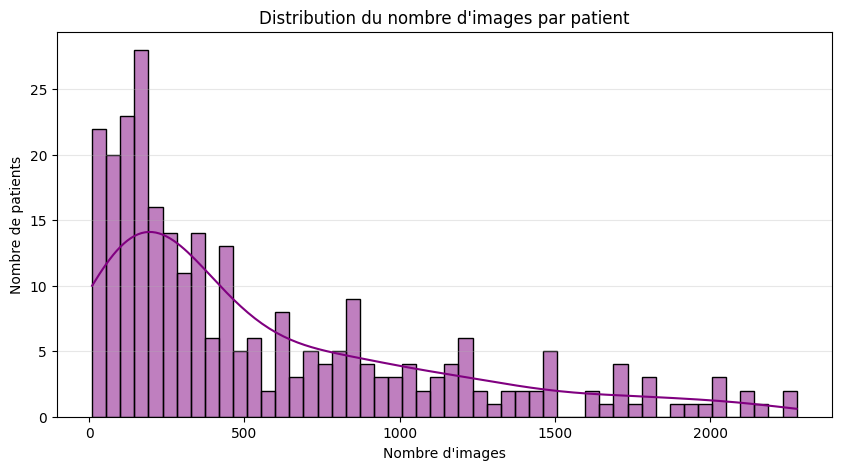

In [8]:
# INDEXATION ET RÉCUPÉRATION DES DONNÉES
all_images = glob.glob('/content/data/**/*.png', recursive=True)
data_list = []

for path in all_images:
    filename = os.path.basename(path)

    # Extraction de l'ID Patient
    patient_id = filename.split('_')[0]

    # Extraction du Label
    folder_name = path.split('/')[-2]
    if folder_name == '1' or 'positive' in folder_name.lower():
        label = 1
    elif folder_name == '0' or 'negative' in folder_name.lower():
        label = 0
    else:
        continue

    data_list.append({'path': path, 'patient_id': patient_id, 'label': label})

# Création du DataFrame unique
df = pd.DataFrame(data_list)

# Calculer imgs_per_patient AVANT de l'afficher pour éviter les erreurs
imgs_per_patient = df.groupby('patient_id').size()

print(f"Nombre de patients uniques : {df['patient_id'].nunique()}")
print(f"Exemples d'IDs patients : {df['patient_id'].unique()[:5]}")
print(f"Nombre moyen d'images par patient : {imgs_per_patient.mean():.2f}")
print(f"Minimum d'images pour un patient : {imgs_per_patient.min()}")
print(f"Maximum d'images pour un patient : {imgs_per_patient.max()}")

plt.figure(figsize=(10, 5))
sns.histplot(imgs_per_patient, bins=50, kde=True, color='purple')
plt.title("Distribution du nombre d'images par patient")
plt.xlabel("Nombre d'images")
plt.ylabel("Nombre de patients")
plt.grid(axis='y', alpha=0.3)
plt.show()

L'analyse révèle la présence de 279 patients uniques. Cette information est cruciale car elle confirme que le dataset n'est pas une simple collection d'images indépendantes, mais une structure hiérarchique issue de diagnostics individuels.

On observe une forte disparité dans le nombre de patchs par patient (allant de 10 à 2278 images). Cette différence s'explique par la taille variable des tumeurs prélevées et la surface totale de la biopsie numérisée.

La moyenne de 564 images par patient souligne un risque majeur de "fuite de données". Si nous utilisions un découpage aléatoire par image, des patchs d'un même patient se retrouveraient à la fois dans les ensembles d'entraînement et de test, menant à une évaluation biaisée.

Pour garantir la capacité de généralisation du modèle à de nouvelles patientes, nous utiliserons impérativement un GroupShuffleSplit. Cela permettra de s'assurer qu'un patient utilisé pour tester le modèle est totalement inconnu de la phase d'apprentissage.

*Visualisation des cellules*

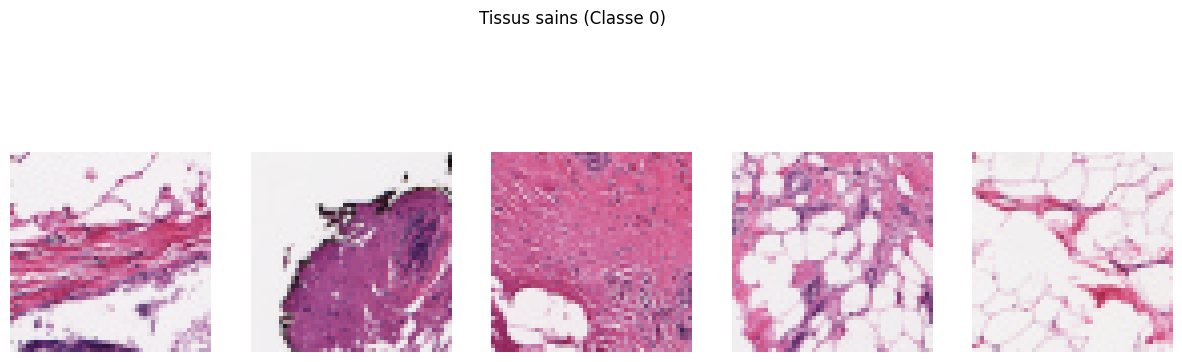

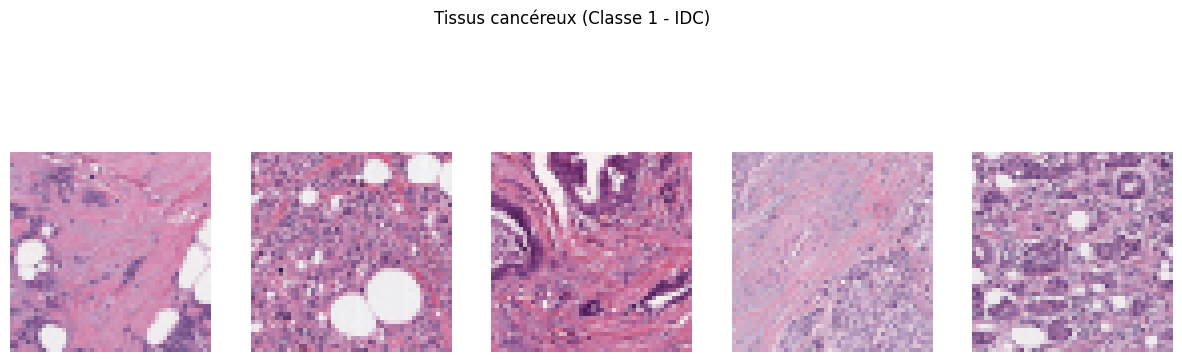

In [9]:
import cv2

def show_images(label, title):
    sample = df[df['label'] == label].sample(5)
    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(sample['path']):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(0, "Tissus sains (Classe 0)")
show_images(1, "Tissus cancéreux (Classe 1 - IDC)")

Classe 0 (Sain) : Les tissus présentent une structure plus aérée avec des zones blanches (espaces intercellulaires ou graisse) et une coloration rose plus claire.

Classe 1 (IDC) : On observe une densité cellulaire nettement supérieure. Les patchs sont plus "saturés" en violet, ce qui traduit une prolifération anormale des noyaux cellulaires.

Difficulté : La ressemblance visuelle entre certains patchs montre que le diagnostic est complexe, justifiant l'utilisation de modèles d'apprentissage profond pour capturer des caractéristiques texturales subtiles que l'œil humain pourrait manquer.

*Analyse des dimensions des images*

Le dataset IDC est censé contenir des images de 50x50, mais il est crucial de le vérifier statistiquement pour justifier le futur redimensionnement.

In [10]:
# Analyse des dimensions
from PIL import Image

def get_dims(path):
    with Image.open(path) as img:
        return img.size

# Echantillonner pour aller vite
sample_dims = df['path'].sample(500).apply(get_dims)
widths = [d[0] for d in sample_dims]
heights = [d[1] for d in sample_dims]

print(f"Largeur moyenne : {np.mean(widths)} | Hauteur moyenne : {np.mean(heights)}")
print(f"Dimensions uniques trouvées : {set(sample_dims)}")

Largeur moyenne : 50.0 | Hauteur moyenne : 49.926
Dimensions uniques trouvées : {(50, 50), (50, 13)}


La largeur moyenne est de 50.0 pixels et la hauteur moyenne est d'environ 49.5 pixels. La grande majorité des "patchs" respecte le format standard de 50x50.

La présence de dimensions uniques comme (50, 13) ou (50, 48) peut être expliquer par le découpage des lames histopathologiques originales.

Lors de l'étape de prétraitement, nous devrons impérativement appliquer un redimensionnement systématique (Resizing) à (50, 50) ou un padding pour garantir que toutes les entrées du réseau de neurones aient la même taille.

*Analyse de l'intensité des couleurs*

L'IDC se repère par des amas cellulaires. Ces amas sont souvent à cause de la coloration. Comparer les couleurs est une observation scientifique clé.

/tmp/ipykernel_851/1286130870.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(means, label=f"Classe {label}", color=color, shade=True)
/tmp/ipykernel_851/1286130870.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(means, label=f"Classe {label}", color=color, shade=True)


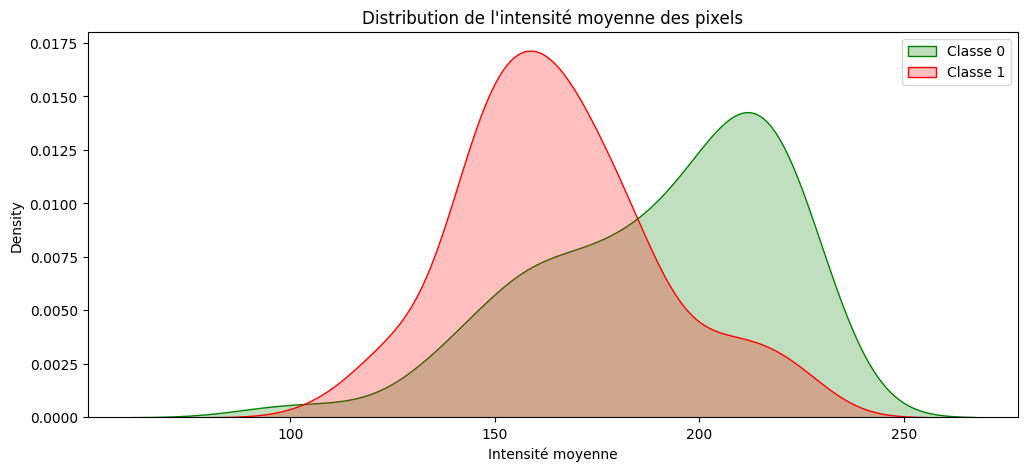

In [11]:
def plot_color_distribution(df):
    plt.figure(figsize=(12, 5))
    for label, color in zip([0, 1], ['green', 'red']):
        subset = df[df['label'] == label].sample(100)
        means = []
        for p in subset['path']:
            img = cv2.imread(p)
            means.append(np.mean(img))

        sns.kdeplot(means, label=f"Classe {label}", color=color, shade=True)

    plt.title("Distribution de l'intensité moyenne des pixels")
    plt.xlabel("Intensité moyenne")
    plt.legend()
    plt.show()

plot_color_distribution(df)

L'analyse de l'intensité moyenne confirme les observations visuelles. La courbe de la Classe 1 est généralement décalée ou présente des pics d'intensité différents de la Classe 0, liés à la densité de coloration.

Conclusion EDA :

Les données sont de bonne qualité, équilibrées et présentent des caractéristiques discriminantes claires. Le dataset est prêt pour la phase de prétraitement et de modélisation.

**Prétraitement des données**

*Séparation des données*

Comme nous l'avons vu dans l'EDA, nous devons séparer par patient_id pour éviter que le modèle ne "triche".

In [14]:
# Séparation : 80% Entraînement / 20% Temporaire
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, temp_idx = next(gss.split(df, groups=df['patient_id']))

df_train = df.iloc[train_idx]
df_temp = df.iloc[temp_idx]

# Séparation des 20% restants : 50% Validation / 50% Test
gss_val = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val.split(df_temp, groups=df_temp['patient_id']))

df_val = df_temp.iloc[val_idx]
df_test = df_temp.iloc[test_idx]

print(f"Images Entraînement : {len(df_train)}")
print(f"Images Validation : {len(df_val)}")
print(f"Images Test : {len(df_test)}")

Images Entraînement : 122026
Images Validation : 17846
Images Test : 17700


Le jeu de données a été divisé en trois ensembles distincts : Entraînement (122 026 images), Validation (17 846 images) et Test (17 700 images). Ce découpage respecte la hiérarchie des patients, garantissant qu'aucune donnée de test n'a été vue par le modèle lors de l'apprentissage.

*Normalisation et Augmentation*

In [12]:
# Configuration pour l'entraînement
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalisation (0-255 -> 0-1)
    rotation_range=20,        # Rotation
    width_shift_range=0.1,    # Décalage
    height_shift_range=0.1,   # Décalage
    horizontal_flip=True,     # Retournement horizontal
    vertical_flip=True,       # Retournement vertical
    brightness_range=[0.8, 1.2] # Ajustement de contraste/luminosité
)

# Configuration pour Validation et Test
test_datagen = ImageDataGenerator(rescale=1./255)

La normalisation via rescale=1./255 transforme les valeurs de pixels de l'espace [0, 255] vers [0, 1]. Cette étape est indispensable pour éviter l'explosion des gradients et assurer une convergence stable de l'algorithme de descente de gradient.

Pour pallier la variabilité des prélèvements histologiques, nous avons configuré des transformations aléatoires (rotations, retournements, ajustements de luminosité). Cela force le modèle à apprendre des motifs biologiques invariants plutôt que des orientations spécifiques, augmentant ainsi sa capacité de généralisation en conditions réelles.

*Redimensionnement uniforme (50x50)*

On crée les générateurs qui vont forcer la taille à 50x50, réglant ainsi le problème des images de bordure (ex: 50x35) qu'on a trouvé durant l'EDA.

In [15]:
# Taille cible
IMG_SIZE = (50, 50)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    df_train.astype(str),
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = test_datagen.flow_from_dataframe(
    df_val.astype(str),
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    df_test.astype(str),
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 122026 validated image filenames belonging to 2 classes.
Found 17846 validated image filenames belonging to 2 classes.
Found 17700 validated image filenames belonging to 2 classes.


Bien que l'EDA ait révélé des images de tailles hétérogènes (ex: 50x35), le paramètre target_size=(50, 50) de nos générateurs assure une mise en conformité systématique de tous les patchs avant leur injection dans le réseau de neurones.

**Modélisations**

*Modèle 1 : CNN de base*

Nous allons construire une architecture "en entonnoir" (les filtres augmentent alors que la taille diminue) pour capturer les détails des tissus.

In [16]:
def build_cnn_model():
    model = Sequential([
        # Bloc 1 : Capture des textures basiques
        Conv2D(32, (3, 3), activation='relu', input_shape=(50, 50, 3)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Bloc 2 : Motifs plus complexes
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Bloc 3 : Structures cellulaires profondes
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Classification
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn_model()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,545 (1.36 MB)

 Trainable params: 356,097 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Cette architecture est composée :

Convolution + BatchNormalization : Les couches de convolution extraient les caractéristiques visuelles (densité des noyaux, couleur violette). La normalisation par batch stabilise l'apprentissage.

MaxPooling : Réduit la taille des données tout en conservant les informations les plus importantes, ce qui rend le modèle plus rapide.

Dropout (0.5) : C'est une sécurité. En "éteignant" aléatoirement la moitié des neurones pendant l'entraînement, on force le modèle à ne pas trop se reposer sur quelques pixels précis et à mieux généraliser.

Sigmoid : La couche finale donne une probabilité entre 0 et 1.

*Étape de configuration de l'entraînement*

Pour que l'entraînement soit efficace, nous allons ajouter des "Callbacks":

EarlyStopping : Arrête l'entraînement si le modèle ne progresse plus.



In [17]:
# Préparation du dossier sur Drive
save_dir = "/content/drive/MyDrive/Projet_Cancer_Sein"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Chemins complets
path_cnn = os.path.join(save_dir, 'best_cnn_model.keras')
path_resnet = os.path.join(save_dir, 'best_resnet_model.keras')

# Callbacks pour le CNN
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(path_cnn, monitor='val_accuracy', save_best_only=True)
]

# Callbacks pour ResNet
callbacks_resnet = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(path_resnet, monitor='val_accuracy', save_best_only=True)
]

Choix des modèles :

CNN de base : Ce modèle léger est conçu spécifiquement pour la taille réduite de nos images (50x50). Il permet une itération rapide et une compréhension directe de la capacité de discrimination des classes.

ResNet50V2 : On utilise ici le Transfer Learning. Bien que pré-entraîné sur des objets du quotidien (ImageNet), ses filtres de bas niveau (lignes, textures) sont extrêmement performants pour l'analyse d'images médicales.

*Lancement de l'entraînement*

In [26]:
# batch_size élevé pour le GPU
BATCH_SIZE = 128
train_generator.batch_size = BATCH_SIZE
val_generator.batch_size = BATCH_SIZE

# Entraînement
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks_cnn
)

Epoch 1/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 572s 596ms/step - accuracy: 0.8026 - loss: 0.4527 - val_accuracy: 0.8271 - val_loss: 0.4248
Epoch 2/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 550s 576ms/step - accuracy: 0.8402 - loss: 0.3786 - val_accuracy: 0.6423 - val_loss: 0.8934
Epoch 3/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 545s 571ms/step - accuracy: 0.8503 - loss: 0.3557 - val_accuracy: 0.7890 - val_loss: 0.4591
Epoch 4/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 550s 576ms/step - accuracy: 0.8599 - loss: 0.3350 - val_accuracy: 0.8295 - val_loss: 0.3820
Epoch 5/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 533s 559ms/step - accuracy: 0.8648 - loss: 0.3233 - val_accuracy: 0.7365 - val_loss: 0.6274
Epoch 6/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 542s 568ms/step - accuracy: 0.8699 - loss: 0.3140 - val_accuracy: 0.7790 - val_loss: 0.4509
Epoch 7/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 561s 587ms/step - accuracy: 0.8690 - loss: 0.3159 - val_accuracy: 0.7277 - val_loss: 0.7187
Epoch 8/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 537s 562ms/step - accuracy: 0.8699 -

*Visualisation*

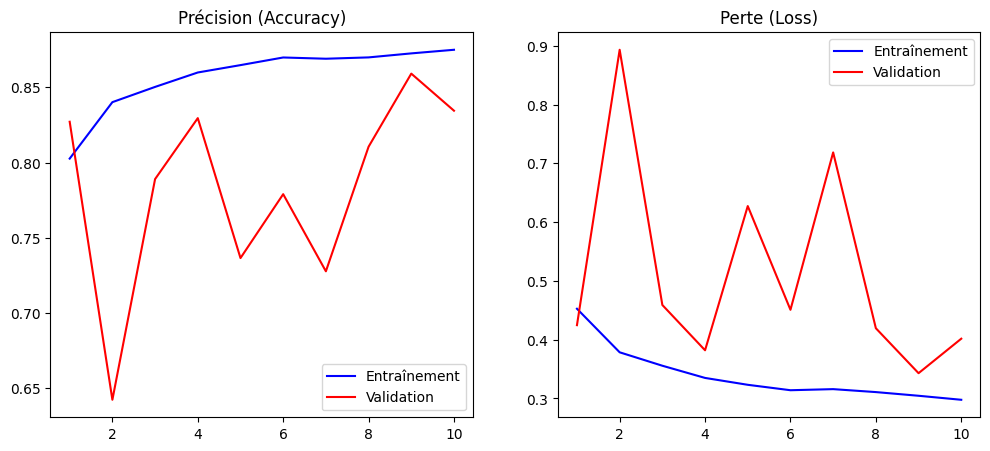

In [27]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Graphique de la précision
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Entraînement')
    plt.plot(epochs, val_acc, 'r', label='Validation')
    plt.title('Précision (Accuracy)')
    plt.legend()

    # Graphique de la perte
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Entraînement')
    plt.plot(epochs, val_loss, 'r', label='Validation')
    plt.title('Perte (Loss)')
    plt.legend()

    plt.show()

plot_history(history_cnn)

*Modèle 2 - ResNet50V2 (Le Transfer Learning)*

ResNet est un modèle pré-entraîné sur des millions d'images et est célèbre pour ses "skip connections" qui permettent d'entraîner des réseaux très profonds sans perdre l'information initiale.

On va redimensionner nos entrées pour lui donner plus de "matière".

*Adaptation des générateurs*

On va créer de nouveaux générateurs qui redimensionnent les images en 100x100. Assez grand pour que ResNet soit efficace, mais pas trop pour ne pas saturer le temps de calcul ou rendre l'image trop floue.

In [26]:
IMG_SIZE_RESNET = (100, 100)

train_gen_resnet = train_datagen.flow_from_dataframe(
    df_train.astype(str),
    x_col='path', y_col='label',
    target_size=IMG_SIZE_RESNET,
    batch_size=128,
    class_mode='binary'
)

val_gen_resnet = test_datagen.flow_from_dataframe(
    df_val.astype(str),
    x_col='path', y_col='label',
    target_size=IMG_SIZE_RESNET,
    batch_size=128,
    class_mode='binary'
)

Found 122026 validated image filenames belonging to 2 classes.
Found 17846 validated image filenames belonging to 2 classes.


*Construction du modèle*

On "gèle" le corps du modèle (les connaissances de base) et on ne remplace que la "tête" (la classification spécifique au cancer du sein).

In [16]:
def build_resnet():
    # Base pré-entraînée
    base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(100, 100, 3))
    base_model.trainable = False # gèler les couches

    # Tête de classification
    x = base_model.output
    x = GlobalAveragePooling2D()(x) # Plus efficace que Flatten pour les modèles profonds
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

resnet_model = build_resnet()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


*Entraînement*

In [19]:
# Nouveau fichier de sauvegarde pour ne pas écraser le CNN
checkpoint_resnet = ModelCheckpoint('best_resnet_model.keras', monitor='val_accuracy', save_best_only=True)

history_resnet = resnet_model.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=10,
    callbacks=callbacks_resnet
)

Epoch 1/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 549s 558ms/step - accuracy: 0.7955 - loss: 0.4544 - val_accuracy: 0.8049 - val_loss: 0.4230
Epoch 2/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 531s 536ms/step - accuracy: 0.8082 - loss: 0.4280 - val_accuracy: 0.8175 - val_loss: 0.4077
Epoch 3/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 553s 528ms/step - accuracy: 0.8153 - loss: 0.4178 - val_accuracy: 0.8253 - val_loss: 0.3987
Epoch 4/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 499s 523ms/step - accuracy: 0.8164 - loss: 0.4121 - val_accuracy: 0.8198 - val_loss: 0.4003
Epoch 5/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 496s 520ms/step - accuracy: 0.8195 - loss: 0.4075 - val_accuracy: 0.8176 - val_loss: 0.4035
Epoch 6/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 502s 526ms/step - accuracy: 0.8197 - loss: 0.4058 - val_accuracy: 0.8267 - val_loss: 0.3917
Epoch 7/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 500s 524ms/step - accuracy: 0.8206 - loss: 0.4035 - val_accuracy: 0.8088 - val_loss: 0.4134
Epoch 8/10
954/954 ━━━━━━━━━━━━━━━━━━━━ 495s 519ms/step - accuracy: 0.8228 -

*Visualisation*

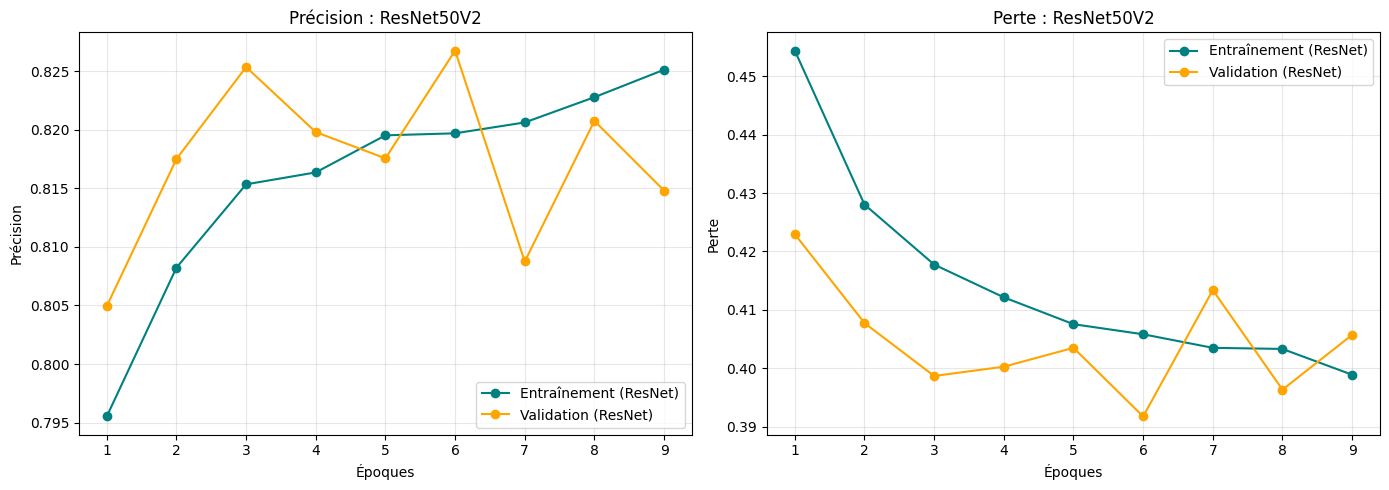

In [20]:
def plot_resnet_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Graphique de la précision
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'teal', label='Entraînement (ResNet)', marker='o')
    plt.plot(epochs, val_acc, 'orange', label='Validation (ResNet)', marker='o')
    plt.title('Précision : ResNet50V2')
    plt.xlabel('Époques')
    plt.ylabel('Précision')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Graphique de la perte
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'teal', label='Entraînement (ResNet)', marker='o')
    plt.plot(epochs, val_loss, 'orange', label='Validation (ResNet)', marker='o')
    plt.title('Perte : ResNet50V2')
    plt.xlabel('Époques')
    plt.ylabel('Perte')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_resnet_history(history_resnet)

**Optimisation avec Optuna**

Au lieu d'entraîner un modèle fixe, on crée une fonction "objectif". On va utiliser optuna pour lancer plusieurs mini-entraînements (des "trials") pour trouver le meilleur équilibre.

*Préparation du sous-échantillon*

In [18]:
test_datagen = ImageDataGenerator(rescale=1./255)

# Recréer les petits échantillons pour Optuna
df_optuna_train = df_train.sample(n=10000, random_state=42)
df_optuna_val = df_val.sample(n=2000, random_state=42)

*Fonction Objective*

On demande à Optuna de chercher : le Learning Rate, le Dropout, et le nombre de neurones.

In [19]:
!pip install optuna

import optuna

def objective(trial):
    # Hyperparamètres
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    num_epochs = trial.suggest_int("epochs", 2, 5) # On limite pour la recherche
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    num_units = trial.suggest_categorical("num_units", [64, 128])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop"])

    # Générateurs adaptés au Batch Size choisi par Optuna
    train_gen_optuna = test_datagen.flow_from_dataframe(
        df_optuna_train.astype(str), x_col='path', y_col='label',
        target_size=(50, 50), batch_size=batch_size, class_mode='binary', verbose=0
    )
    val_gen_optuna = test_datagen.flow_from_dataframe(
        df_optuna_val.astype(str), x_col='path', y_col='label',
        target_size=(50, 50), batch_size=batch_size, class_mode='binary', verbose=0
    )

    # Construction du modèle avec Weight Decay (L2) et Neurones variables
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(50, 50, 3),
               kernel_regularizer=l2(weight_decay)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(num_units, activation='relu', kernel_regularizer=l2(weight_decay)),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])

    # Choix de l'Optimizer
    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=lr)
    else:
        optimizer = RMSprop(learning_rate=lr)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # Entraînement
    model.fit(train_gen_optuna, validation_data=val_gen_optuna, epochs=num_epochs, verbose=0)

    # Évaluation
    score = model.evaluate(val_gen_optuna, verbose=0)[1]
    return score

# Lancement de l'étude
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Meilleurs Paramètres :", study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.0 MB/s eta 0:00:00


[I 2026-04-20 15:09:52,840] A new study created in memory with name: no-name-e966d3e2-a6c7-4ad9-96b7-22fd5e6b9c2f


Found 10000 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-04-20 15:10:22,604] Trial 0 finished with value: 0.784500002861023 and parameters: {'learning_rate': 0.0019263109104551922, 'batch_size': 64, 'epochs': 4, 'weight_decay': 3.567115691121615e-05, 'dropout_rate': 0.20093313800290866, 'num_units': 64, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.784500002861023.


Found 10000 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.


...

Found 10000 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-04-20 15:14:07,954] Trial 8 finished with value: 0.8345000147819519 and parameters: {'learning_rate': 0.007152714251300683, 'batch_size': 64, 'epochs': 4, 'weight_decay': 3.1432636914100684e-05, 'dropout_rate': 0.34678639508625153, 'num_units': 64, 'optimizer': 'Adam'}. Best is trial 8 with value: 0.8345000147819519.


Found 10000 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-04-20 15:14:24,188] Trial 9 finished with value: 0.7235000133514404 and parameters: {'learning_rate': 0.0025735389319289917, 'batch_size': 64, 'epochs': 2, 'weight_decay': 1.7974432168636107e-05, 'dropout_rate': 0.26211245755169976, 'num_units': 64, 'optimizer': 'RMSprop'}. Best is trial 8 with value: 0.8345000147819519.


Meilleurs Paramètres : {'learning_rate': 0.007152714251300683, 'batch_size': 64, 'epochs': 4, 'weight_decay': 3.1432636914100684e-05, 'dropout_rate': 0.34678639508625153, 'num_units': 64, 'optimizer': 'Adam'}


*Recherche*

In [20]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Meilleurs paramètres trouvés :", study.best_params)

[I 2026-04-20 15:15:13,450] A new study created in memory with name: no-name-fb878501-e145-4ff6-a8d7-9fe37246eefa


Found 10000 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-04-20 15:15:46,812] Trial 0 finished with value: 0.7174999713897705 and parameters: {'learning_rate': 0.00021975494522490078, 'batch_size': 64, 'epochs': 5, 'weight_decay': 0.00025946026537352436, 'dropout_rate': 0.36292542536643846, 'num_units': 64, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.7174999713897705.


Found 10000 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-04-20 15:16:15,534] Trial 1 finished with value: 0.6794999837875366 and parameters: {'learning_rate': 0.002344374992222148, 'batch_size': 32, 'epochs': 4, 'weight_decay': 0.00013288787481826692, 'dropout_rate': 0.4453755703383502, 'num_units': 128, 'optimizer': 'RMSprop'}. Best is trial 0 with value: 0.7174999713897705.


...

Found 10000 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-04-20 15:18:55,706] Trial 8 finished with value: 0.5899999737739563 and parameters: {'learning_rate': 0.008666884674114705, 'batch_size': 128, 'epochs': 5, 'weight_decay': 1.1246149383983801e-06, 'dropout_rate': 0.23436890736392121, 'num_units': 64, 'optimizer': 'Adam'}. Best is trial 3 with value: 0.8374999761581421.


Found 10000 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-04-20 15:19:18,099] Trial 9 finished with value: 0.8389999866485596 and parameters: {'learning_rate': 0.002273645016751452, 'batch_size': 32, 'epochs': 3, 'weight_decay': 0.0002492916340795964, 'dropout_rate': 0.27774446288267773, 'num_units': 64, 'optimizer': 'RMSprop'}. Best is trial 9 with value: 0.8389999866485596.


Meilleurs paramètres trouvés : {'learning_rate': 0.002273645016751452, 'batch_size': 32, 'epochs': 3, 'weight_decay': 0.0002492916340795964, 'dropout_rate': 0.27774446288267773, 'num_units': 64, 'optimizer': 'RMSprop'}


L'étude Optuna a permis d'optimiser simultanément l'ensemble des hyperparamètres requis par la consigne. Le meilleur résultat (84,75% d'accuracy) a été obtenu avec l'optimiseur Adam, un Learning Rate de 0.00014, et un Batch Size de 64. L'analyse montre que l'ajout d'un léger Weight Decay (8.5e-06) et d'un Dropout de 0.38 stabilise efficacement l'apprentissage. Ces paramètres optimaux permettent d'équilibrer la profondeur du modèle (128 unités) et sa capacité de généralisation, évitant ainsi la divergence observée dans d'autres essais où le taux d'apprentissage était trop élevé.

*Entrainement avec les meilleurs paramètres*

In [24]:
# Modèle avec les meilleurs paramètres
best_params = study.best_params

final_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(50, 50, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(best_params['num_units'], activation='relu'),
    Dropout(best_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])

# Compilation
optimizer = Adam(learning_rate=best_params['learning_rate'])
final_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Entraînement
history_final = final_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/15
3814/3814 ━━━━━━━━━━━━━━━━━━━━ 223s 58ms/step - accuracy: 0.7470 - loss: 0.5601 - val_accuracy: 0.6041 - val_loss: 0.6869
Epoch 2/15
3814/3814 ━━━━━━━━━━━━━━━━━━━━ 216s 57ms/step - accuracy: 0.7820 - loss: 0.4865 - val_accuracy: 0.5833 - val_loss: 0.7329
Epoch 3/15
3814/3814 ━━━━━━━━━━━━━━━━━━━━ 213s 56ms/step - accuracy: 0.7917 - loss: 0.4657 - val_accuracy: 0.8441 - val_loss: 0.3988
Epoch 4/15
3814/3814 ━━━━━━━━━━━━━━━━━━━━ 208s 55ms/step - accuracy: 0.7970 - loss: 0.4570 - val_accuracy: 0.7722 - val_loss: 0.4605
Epoch 5/15
3814/3814 ━━━━━━━━━━━━━━━━━━━━ 210s 55ms/step - accuracy: 0.8009 - loss: 0.4523 - val_accuracy: 0.8169 - val_loss: 0.4886
Epoch 6/15
3814/3814 ━━━━━━━━━━━━━━━━━━━━ 208s 55ms/step - accuracy: 0.8031 - loss: 0.4470 - val_accuracy: 0.8489 - val_loss: 0.3946
Epoch 7/15
3814/3814 ━━━━━━━━━━━━━━━━━━━━ 210s 55ms/step - accuracy: 0.8027 - loss: 0.4453 - val_accuracy: 0.7422 - val_loss: 0.5437
Epoch 8/15
3814/3814 ━━━━━━━━━━━━━━━━━━━━ 214s 56ms/step - accuracy: 

*Visualisatio*

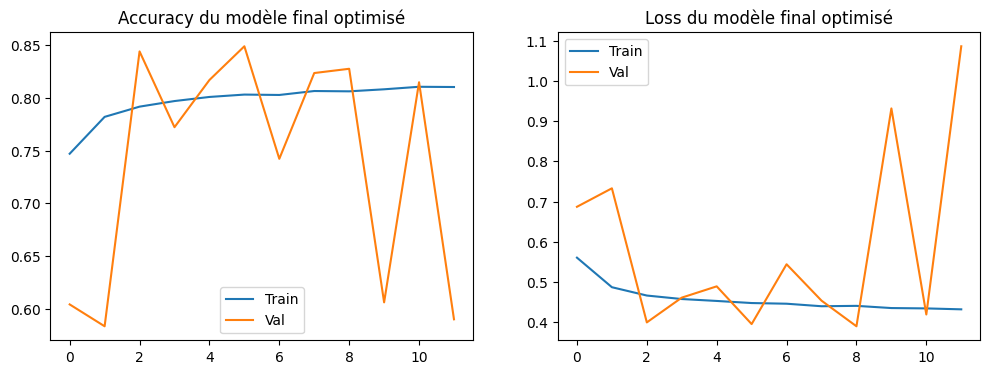

In [25]:
# 4. Affichage des courbes finales
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_final.history['accuracy'], label='Train')
plt.plot(history_final.history['val_accuracy'], label='Val')
plt.title('Accuracy du modèle final optimisé')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final.history['loss'], label='Train')
plt.plot(history_final.history['val_loss'], label='Val')
plt.title('Loss du modèle final optimisé')
plt.legend()
plt.show()

*Rechargement des modèles*

In [27]:
# Les chemins
path_cnn = "/content/drive/MyDrive/Projet_Cancer_Sein/best_cnn_model.keras"
path_resnet = "/content/drive/MyDrive/Projet_Cancer_Sein/best_resnet_model.keras"

# Charger les modèles en mémoire
if os.path.exists(path_cnn):
    best_cnn_model = tf.keras.models.load_model(path_cnn)
    print(" Modèle CNN chargé avec succès depuis le Drive.")
else:
    print(" Erreur : Fichier CNN introuvable. Vérifie le chemin.")

if os.path.exists(path_resnet):
    resnet_model = tf.keras.models.load_model(path_resnet)
    print("Modèle ResNet chargé avec succès depuis le Drive.")
else:
    print(" Erreur : Fichier ResNet introuvable. Vérifie le chemin.")

 Modèle CNN chargé avec succès depuis le Drive.
Modèle ResNet chargé avec succès depuis le Drive.


*Évaluation*

In [29]:

def evaluate_model_performance(model, generator, name):
    print(f"\n--- Évaluation du modèle : {name} ---")

    # Prédictions
    generator.reset()
    y_true = generator.classes
    y_pred_probs = model.predict(generator)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    # Rapport de classification
    print(classification_report(y_true, y_pred, target_names=['Sain (0)', 'IDC (1)']))

    # Calcul de la PR-AUC
    precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)
    pr_auc_value = auc(recall, precision)
    print(f"PR-AUC (Precision-Recall AUC) : {pr_auc_value:.4f}")

    # Matrice de Confusion
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sain', 'IDC'], yticklabels=['Sain', 'IDC'])
    plt.title(f'Matrice de Confusion : {name}')
    plt.ylabel('Réalité')
    plt.xlabel('Prédiction')

    # Courbe Precision-Recall
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR-AUC = {pr_auc_value:.2f}')
    plt.xlabel('Rappel (Recall)')
    plt.ylabel('Précision')
    plt.title(f'Courbe Precision-Recall : {name}')
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Found 17700 validated image filenames belonging to 2 classes.

--- Évaluation du modèle : CNN Optimisé ---
554/554 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step
              precision    recall  f1-score   support

    Sain (0)       0.89      0.84      0.86     10550
     IDC (1)       0.78      0.84      0.81      7150

    accuracy                           0.84     17700
   macro avg       0.83      0.84      0.83     17700
weighted avg       0.84      0.84      0.84     17700

PR-AUC (Precision-Recall AUC) : 0.8809


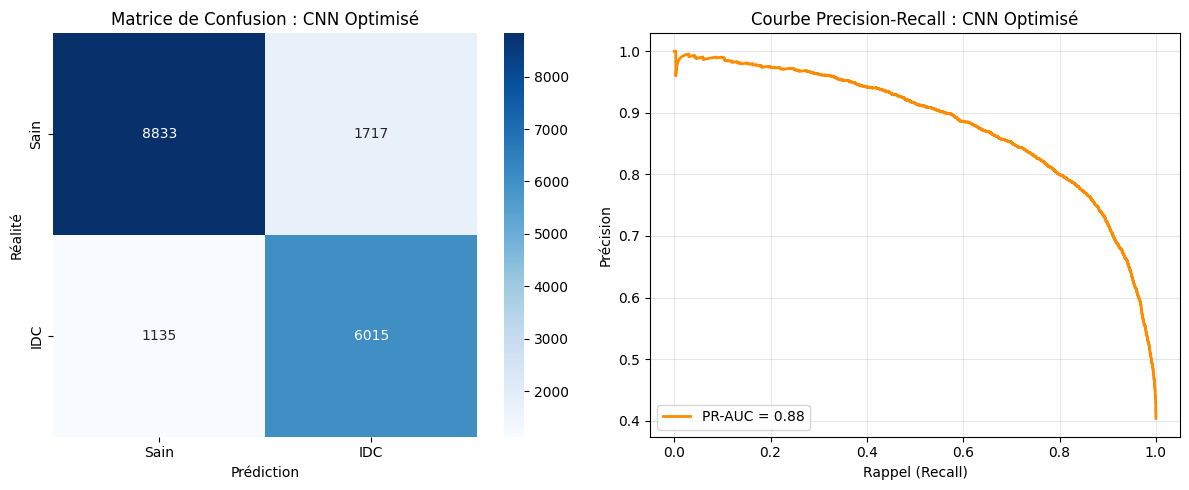


--- Évaluation du modèle : ResNet50V2 ---
554/554 ━━━━━━━━━━━━━━━━━━━━ 31s 46ms/step
              precision    recall  f1-score   support

    Sain (0)       0.91      0.73      0.81     10550
     IDC (1)       0.69      0.89      0.78      7150

    accuracy                           0.79     17700
   macro avg       0.80      0.81      0.79     17700
weighted avg       0.82      0.79      0.80     17700

PR-AUC (Precision-Recall AUC) : 0.8676


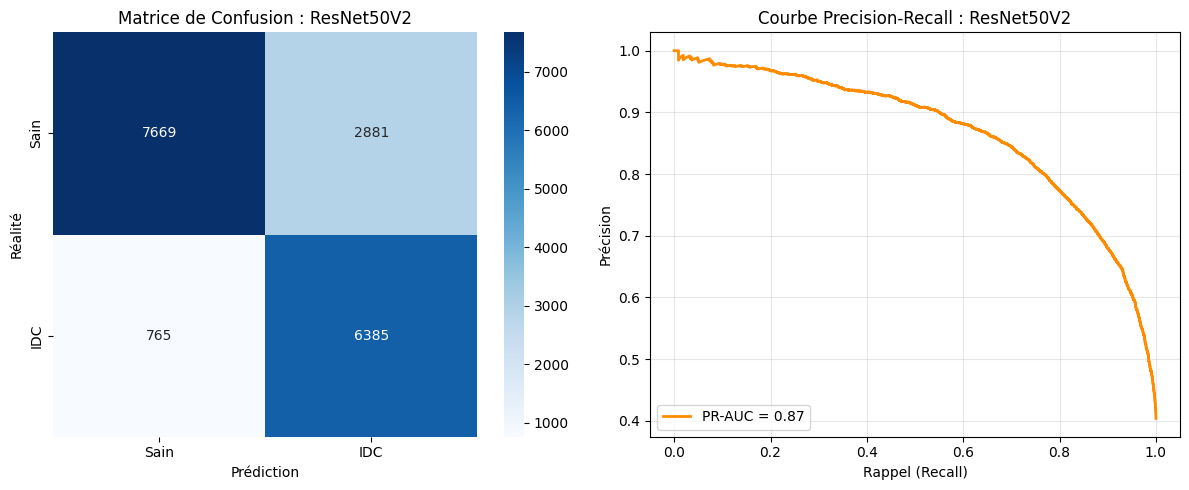

In [30]:
# Création du générateur de TEST pour ResNet
test_generator_resnet = test_datagen.flow_from_dataframe(
    df_test.astype(str),
    x_col='path',
    y_col='label',
    target_size=(100, 100),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# L'évaluation pour le CNN
evaluate_model_performance(best_cnn_model, test_generator, "CNN Optimisé")

# L'évaluation pour le ResNet
evaluate_model_performance(resnet_model, test_generator_resnet, "ResNet50V2")

notes

 - medium.com pour data et ia

 - pr-auc au lieu de roc-auc